In [1]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain, product
import bisect
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import warnings
warnings.filterwarnings("ignore")
seed = 1729928109

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'uci'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/uci/ml_uci.csv


,u,i,ts,label,idx
0,1,2,0,0,1
1,3,4,114878,0,2
2,5,2,373430,0,3
3,6,7,398658,0,4
4,8,7,398795,0,5


In [2]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [3]:
# sparsification 
sprs_type = 'ts_tpr_remove_mss'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
# sprs_df.drop(['Unnamed: 0'], axis=1, inplace=True)
sprs_df.head()

,u,i,ts,label,idx
0,3,4,114878,0,2
1,5,2,373430,0,3
2,6,7,398658,0,4
3,8,7,398795,0,5
4,9,10,399442,0,6


## Helper Function

In [4]:
def calculate_node_degrees(df):
    """Calculates the degree for source and destination nodes separately."""
    src_degrees = Counter(df['u'])
    dst_degrees = Counter(df['i'])
    return src_degrees, dst_degrees


# def check_c3_compliance(df, negative_samples, time_window=1200*1e3):
#     df_sorted = df.sort_values('ts')
#     compliant = []
#     for u, i, ts in negative_samples:
#         window_start = max(ts - time_window, df_sorted['ts'].min())
#         window_df = df_sorted[(df_sorted['ts'] >= window_start) & (df_sorted['ts'] <= ts)]
#         nodes_in_window = set(window_df['u']) | set(window_df['i'])
#         compliant.append((u in nodes_in_window) and (i in nodes_in_window))
#     return compliant

def check_c3_compliance(df, negative_samples, W=1200):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        # Find insertion point index
        insert_idx = df_sorted[df_sorted['ts'] <= ts].shape[0]
        # Get previous W edges
        window_start_idx = max(0, insert_idx - W)
        window_df = df_sorted.iloc[window_start_idx:insert_idx]
        # Get valid nodes from window
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant


def get_nodes_in_time_window(df: pd.DataFrame, current_time: float, window: int) -> Set[int]:
    """
    Get the set of nodes that were active within the time window before current_time.
    
    Args:
    df (pd.DataFrame): DataFrame with interactions ('u' for source, 'i' for destination, 'ts' for timestamp)
    current_time (float): Current timestamp
    window (int): Time window size
    
    Returns:
    Set[int]: Set of nodes active within the time window
    """
    window_start = max(current_time - window, df['ts'].min())
    window_df = df[(df['ts'] >= window_start) & (df['ts'] <= current_time)]
    return set(window_df['u']) | set(window_df['i'])

class Old_TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200):
        self.original_graph = original_graph
        self.seed=seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.initialize_kde()
        self.initialize_kd_tree()

    def initialize_kde(self):
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        self.kde = stats.gaussian_kde(inter_event_times)
        # Set the random state for KDE
        # self.kde.set_bandwidth(bw_method=self.kde.factor)
        # self.kde.reseed(self.seed)

    def initialize_kd_tree(self):
        self.temporal_kd_tree = cKDTree(self.original_graph['ts'].values.reshape(-1, 1))

    def assign_timestamps(self, num_samples):
        kde_samples = self.kde.resample(num_samples, self.rng)[0]
        cumulative_times = np.cumsum(kde_samples) + self.min_time
        cumulative_times = np.clip(cumulative_times, self.min_time, self.max_time)
        jitter = self.rng.uniform(0, self.time_window * 0.1, num_samples)
        sampled_timestamps = cumulative_times + jitter
        sampled_timestamps.sort()
        sampled_timestamps = np.clip(sampled_timestamps, self.min_time, self.max_time)
        return sampled_timestamps

    def find_next_events(self, timestamps):
        _, indices = self.temporal_kd_tree.query(timestamps.reshape(-1, 1), k=1)
        return self.original_graph['ts'].values[indices]

def create_node_mapping(original_degrees: Dict[int, int], generated_degrees: Dict[int, int]) -> Dict[int, int]:
    """
    Create a one-to-one mapping between generated and original nodes based on degree.
    
    Args:
    original_degrees (Dict[int, int]): Degree distribution of original nodes
    generated_degrees (Dict[int, int]): Degree distribution of generated nodes
    
    Returns:
    Dict[int, int]: Mapping from generated nodes to original nodes
    """
    degree_to_nodes = defaultdict(list)
    for node, degree in original_degrees.items():
        degree_to_nodes[degree].append(node)
    
    generated_degree_to_nodes = defaultdict(list)
    for node, degree in generated_degrees.items():
        generated_degree_to_nodes[degree].append(node)
    
    mapping = {}
    for degree, nodes in degree_to_nodes.items():
        generated_nodes = generated_degree_to_nodes.get(degree, [])
        for original_node, generated_node in zip(nodes, generated_nodes):
            mapping[generated_node] = original_node
    
    return mapping

In [5]:
class TemporalSampler:
    def __init__(self, original_graph, seed=None, time_window=1200, 
                 num_bins=100, min_activity_threshold=2):
        """
        Enhanced Temporal Sampler with activity awareness and adaptive sampling
        
        Args:
            original_graph: DataFrame with 'ts', 'u', 'i' columns
            seed: Random seed
            time_window: Time window size for node availability
            num_bins: Number of temporal bins for activity analysis
            min_activity_threshold: Minimum number of nodes required in a time period
        """
        self.original_graph = original_graph
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.time_window = time_window
        self.num_bins = num_bins
        self.min_activity_threshold = min_activity_threshold
        
        # Time bounds
        self.min_time = min(0, original_graph['ts'].min())
        self.max_time = original_graph['ts'].max()
        self.time_range = self.max_time - self.min_time
        
        # Initialize components
        self._compute_activity_density()
        self._initialize_kde()
        self._initialize_node_windows()
        
    def _compute_activity_density(self):
        """Compute temporal activity density and identify active periods"""
        # Create temporal bins
        self.bin_edges = np.linspace(self.min_time, self.max_time, self.num_bins + 1)
        self.bin_width = (self.max_time - self.min_time) / self.num_bins
        
        # Compute activity density
        df_sorted = self.original_graph.sort_values('ts')
        hist, _ = np.histogram(df_sorted['ts'], bins=self.bin_edges)
        self.activity_density = hist / hist.sum()
        
        # Track node activities
        self.src_activity = defaultdict(list)
        self.dst_activity = defaultdict(list)
        
        for _, row in df_sorted.iterrows():
            bin_idx = np.searchsorted(self.bin_edges, row['ts']) - 1
            if bin_idx < self.num_bins:
                self.src_activity[row['u']].append(bin_idx)
                self.dst_activity[row['i']].append(bin_idx)
        
        # Identify active periods
        self.active_bins = np.where(hist >= self.min_activity_threshold)[0]
        self.active_periods = self._merge_active_periods()
        
    def _merge_active_periods(self):
        """Merge consecutive active periods"""
        if len(self.active_bins) == 0:
            return []
            
        periods = []
        start = self.active_bins[0]
        prev = start
        
        for bin_idx in self.active_bins[1:]:
            if bin_idx - prev > 1:
                periods.append((
                    self.bin_edges[start],
                    self.bin_edges[prev + 1]
                ))
                start = bin_idx
            prev = bin_idx
            
        periods.append((
            self.bin_edges[start],
            self.bin_edges[prev + 1]
        ))
        
        return periods
        
    def _initialize_kde(self):
        """Initialize adaptive KDE with local bandwidth"""
        df_sorted = self.original_graph.sort_values('ts')
        inter_event_times = np.diff(df_sorted['ts'])
        
        # Compute local density for adaptive bandwidth
        local_density = []
        window_size = len(inter_event_times) // 20  # 5% of data
        
        for i in range(len(inter_event_times)):
            start_idx = max(0, i - window_size//2)
            end_idx = min(len(inter_event_times), i + window_size//2)
            local_density.append(len(inter_event_times[start_idx:end_idx]))
            
        local_density = np.array(local_density)
        self.bandwidths = 1 / np.sqrt(local_density + 1)  # Adaptive bandwidth
        
        # Initialize KDE with adaptive bandwidth
        self.kde = stats.gaussian_kde(
            inter_event_times,
            bw_method=np.mean(self.bandwidths)
        )
        
    def _initialize_node_windows(self):
        """Track node availability windows"""
        df_sorted = self.original_graph.sort_values('ts')
        self.node_windows = defaultdict(list)
        
        window_starts = df_sorted['ts'].values
        window_ends = window_starts + self.time_window
        
        for ts, u, i in df_sorted[['ts', 'u', 'i']].values:
            self.node_windows[u].append((ts, ts + self.time_window))
            self.node_windows[i].append((ts, ts + self.time_window))
            
        # Merge overlapping windows
        for node in self.node_windows:
            merged = []
            current = None
            
            for window in sorted(self.node_windows[node]):
                if current is None:
                    current = list(window)
                elif window[0] <= current[1]:
                    current[1] = max(current[1], window[1])
                else:
                    merged.append(tuple(current))
                    current = list(window)
                    
            if current is not None:
                merged.append(tuple(current))
                
            self.node_windows[node] = merged

    def assign_timestamps(self, num_samples):
        """
        Assign timestamps using activity-aware sampling
        """
        sampled_timestamps = []
        required_samples = num_samples
        
        # Sample from active periods with higher probability
        while len(sampled_timestamps) < required_samples:
            # Choose active period weighted by activity density
            period_weights = [
                np.sum(self.activity_density[
                    np.searchsorted(self.bin_edges, start):
                    np.searchsorted(self.bin_edges, end)
                ])
                for start, end in self.active_periods
            ]
            period_weights = np.array(period_weights) / np.sum(period_weights)
            
            chosen_period = self.active_periods[
                self.rng.choice(len(self.active_periods), p=period_weights)
            ]
            
            # Sample timestamps within chosen period
            local_samples = min(
                required_samples - len(sampled_timestamps),
                max(1, int(required_samples * period_weights[0]))
            )
            
            # Generate samples using KDE
            kde_samples = self.kde.resample(local_samples, self.rng)[0]
            timestamps = np.cumsum(kde_samples) + chosen_period[0]
            timestamps = timestamps[timestamps <= chosen_period[1]]
            
            # Add jitter while maintaining window constraints
            jitter = self.rng.uniform(
                -self.time_window * 0.05,
                self.time_window * 0.05,
                len(timestamps)
            )
            timestamps += jitter
            
            # Ensure timestamps are within bounds
            timestamps = np.clip(timestamps, self.min_time, self.max_time)
            sampled_timestamps.extend(timestamps)
            
        sampled_timestamps = np.array(sorted(sampled_timestamps[:num_samples]))
        return sampled_timestamps
        
    def get_activity_metrics(self):
        """Return activity metrics for analysis"""
        return {
            'activity_density': self.activity_density,
            'active_periods': self.active_periods,
            'bin_edges': self.bin_edges,
            'total_active_bins': len(self.active_bins)
        }

In [6]:
# VFinal

class EdgeTimestampSelector:
   def __init__(self,
                feasible_edges_dict: Dict,
                original_df: pd.DataFrame, 
                degree_dict: Dict[int, int],
                removed_edges: Set[Tuple[int, int]],
                src_nodes: Optional[Set[int]] = None,
                dst_nodes: Optional[Set[int]] = None,
                time_window:int=1200):
       """Initialize Edge-Timestamp Selector"""
       self.feasible_edges_dict = feasible_edges_dict
       self.original_df = original_df
       self.degree_dict = degree_dict
       self.removed_edges = removed_edges
       self.is_bipartite = src_nodes is not None and dst_nodes is not None
       self.src_nodes = src_nodes
       self.dst_nodes = dst_nodes
       self.time_window = time_window
       
       # Initialize tracking structures
       self.node_usage = defaultdict(int)
       self.selected_pairs = []
       self.remaining_capacity = deepcopy(degree_dict)
       
       # Calculate edge budget and create lookup structures
       self.max_edges = self._calculate_edge_budget()
       self.node_to_edges = self._create_node_edge_mapping()
       self.feasible_adj_lists = self._create_adj_lists()
           
   def _calculate_edge_budget(self) -> int:
       """Calculate maximum possible edges"""
       if self.is_bipartite:
           src_sum = sum(self.degree_dict[n] for n in self.src_nodes)
           dst_sum = sum(self.degree_dict[n] for n in self.dst_nodes)
           return src_sum
       return sum(self.degree_dict.values()) // 2
       
   def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
       """Create mapping from nodes to their edges"""
       node_to_edges = defaultdict(list)
       for edge in self.feasible_edges_dict:
           u, v = edge
           node_to_edges[u].append(edge)
           node_to_edges[v].append(edge)
       return node_to_edges

   def _create_adj_lists(self) -> Dict[int, Set[int]]:
       """Create adjacency lists for faster lookup"""
       adj_lists = defaultdict(set)
       for (u, v) in self.feasible_edges_dict:
           adj_lists[u].add(v)
           if not self.is_bipartite:
               adj_lists[v].add(u)
       return adj_lists
       
   def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
       """Main edge selection algorithm"""
       # Sort nodes by degree for priority
       priority_nodes = sorted(
           self.degree_dict.keys(),
           key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
           reverse=True
       )
       
       selected_count = 0
       pbar = tqdm(total=self.max_edges, desc="Selecting edges")
       
       # Initial edge selection phase
       for node in priority_nodes:
           if selected_count >= self.max_edges:
               break
               
           if self.remaining_capacity[node] <= 0:
               continue
               
           while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
               candidates = self._get_candidates(node)
               if not candidates:
                   break
                   
               scored_candidates = [
                   (self._calculate_score(edge, timestamps), edge, timestamps) 
                   for edge, timestamps in candidates
               ]
               scored_candidates.sort(reverse=True)
               
               selected = False
               for _, edge, timestamps in scored_candidates:
                   if self._can_select(edge, timestamps):
                       best_timestamp = self._pick_best_timestamp(timestamps, edge)
                       self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                       self._update_tracking(edge)
                       selected_count += 1
                       pbar.update(1)
                       selected = True
                       break
                       
               if not selected:
                   break
       
       # Recovery phase if needed
       if selected_count < self.max_edges:
           remaining = self.max_edges - selected_count
           additional_edges = self._fast_recovery_phase(remaining, self.original_df)
           selected_count += len(additional_edges)
           pbar.update(len(additional_edges))
       
       pbar.close()
       self._validate_selections()
       return self.selected_pairs

   def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
       """Recovery phase with C3 compliance and optimized window queries"""
       additional_edges = []
       
       # Pre-process data
       df_sorted = original_df.sort_values('ts').set_index('ts')
       node_appearances = defaultdict(list)
       for idx, row in df_sorted.iterrows():
           node_appearances[row['u']].append(idx)
           node_appearances[row['i']].append(idx)
       
       available_src_nodes = [n for n in self.src_nodes if self.remaining_capacity[n] > 0]
       available_dst_nodes = [n for n in self.dst_nodes if self.remaining_capacity[n] > 0]
       used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
       
       all_timestamps = sorted(list(set(
           ts for timestamps in self.feasible_edges_dict.values() 
           for ts in timestamps
       )))
       
       window_cache = {}
       window_size = self.time_window*1e3
    #    window_size = 1200*1e3  # original
       
       def get_nodes_in_window(timestamp: float) -> Set[int]:
           if timestamp in window_cache:
               return window_cache[timestamp]
               
           window_start = max(timestamp - window_size, df_sorted.index.min())
           nodes_in_window = set()
           
           for node in chain(available_src_nodes, available_dst_nodes):
               appearances = node_appearances[node]
               idx = bisect.bisect_left(appearances, window_start)
               if idx < len(appearances) and appearances[idx] <= timestamp:
                   nodes_in_window.add(node)
           
           window_cache[timestamp] = nodes_in_window
           return nodes_in_window
       
       # Process timestamps in batches
       batch_size = 1000
       for i in range(0, len(all_timestamps), batch_size):
           batch_timestamps = all_timestamps[i:i + batch_size]
           
           for ts in batch_timestamps:
               get_nodes_in_window(ts)
           
           for timestamp in batch_timestamps:
               if len(additional_edges) >= needed_edges:
                   break
                   
               nodes_in_window = window_cache[timestamp]
               valid_src = [n for n in available_src_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               valid_dst = [n for n in available_dst_nodes 
                          if n in nodes_in_window and self.remaining_capacity[n] > 0]
               
               for src_node in valid_src:
                   if len(additional_edges) >= needed_edges:
                       break
                       
                   for dst_node in valid_dst:
                       edge = (src_node, dst_node)
                       if edge not in used_pairs and self._can_select(edge, [timestamp]):
                           additional_edges.append((src_node, dst_node, timestamp))
                           used_pairs.add(edge)
                           self._update_tracking(edge)
                           
                           if len(additional_edges) >= needed_edges:
                               break
                               
           window_cache.clear()
       
       self.selected_pairs.extend(additional_edges)
       return additional_edges

   def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
       """Get valid candidate edges for a node"""
       return [(edge, self.feasible_edges_dict[edge]) 
               for edge in self.node_to_edges[node]
               if self.remaining_capacity[self._get_other_node(edge, node)] > 0 
               and edge in self.feasible_edges_dict]

   def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
       """Get the other node in an edge"""
       u, v = edge
       return v if node == u else u
       
   def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
       """Calculate score for candidate edge"""
       u, v = edge
       score = (self.remaining_capacity[u] + self.remaining_capacity[v] + 
               len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
       if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
           score += 50
       return score
       
   def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
       """Check if edge can be selected"""
       u, v = edge
       if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
           return False
       if self.is_bipartite and ((u in self.src_nodes and v in self.src_nodes) or 
                                (u in self.dst_nodes and v in self.dst_nodes)):
           return False
       return True

   def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
       """Select best timestamp from available options"""
       return min(timestamps)

   def _update_tracking(self, edge: Tuple[int, int]):
       """Update tracking after edge selection"""
       u, v = edge
       self.remaining_capacity[u] -= 1
       self.remaining_capacity[v] -= 1
       self.node_usage[u] += 1
       self.node_usage[v] += 1

   def _validate_selections(self):
       """Validate final selections"""
       node_counts = defaultdict(int)
       for u, v, _ in self.selected_pairs:
           node_counts[u] += 1
           node_counts[v] += 1
           
       src_used = len([n for n in node_counts if n in self.src_nodes])
       dst_used = len([n for n in node_counts if n in self.dst_nodes])
       
       if self.is_bipartite:
           print(f"Source nodes used: {src_used}")
           print(f"Destination nodes used: {dst_used}")

In [7]:
from collections import defaultdict


def optimize_c3_checking(df, time_window=1200*1e3):
    """Precompute node appearance windows for faster C3 checking"""
    df_sorted = df.sort_values('ts')
    
    # Precompute node appearances
    node_appearances = defaultdict(list)
    for _, row in df_sorted.iterrows():
        node_appearances[row['u']].append(row['ts'])
        node_appearances[row['i']].append(row['ts'])
    
    # Sort appearances for binary search
    for node in node_appearances:
        node_appearances[node] = np.array(sorted(node_appearances[node]))
    
    return node_appearances

def fast_check_c3_compliance(node_appearances, negative_samples, time_window=1200*1e3):
    """
    Fast C3 compliance checking using binary search
    
    Args:
        node_appearances: Dict mapping nodes to sorted arrays of their timestamps
        negative_samples: List/array of (u, i, ts) tuples to check
        time_window: Time window size
    """
    compliant = []
    
    for u, i, ts in negative_samples:
        # Check source node
        u_times = node_appearances.get(u, [])
        if len(u_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in u's appearances
        window_start = ts - time_window
        u_idx = np.searchsorted(u_times, window_start)
        if u_idx >= len(u_times) or u_times[u_idx] > ts:
            compliant.append(False)
            continue
            
        # Check destination node
        i_times = node_appearances.get(i, [])
        if len(i_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in i's appearances
        i_idx = np.searchsorted(i_times, window_start)
        if i_idx >= len(i_times) or i_times[i_idx] > ts:
            compliant.append(False)
            continue
            
        compliant.append(True)
        
    return compliant

def check_c3_compliance_optimized(df, negative_samples, time_window=1200*1e3):
    """Wrapper for optimized C3 checking"""
    # Precompute once
    node_appearances = optimize_c3_checking(df, time_window)
    
    # Check compliance
    return fast_check_c3_compliance(node_appearances, negative_samples, time_window)

## Utils

In [8]:
def get_filtered_dataframes(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame,
    start_time: float = None,
    end_time: float = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Filter both dataframes based on time window.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        start_time: Starting timestamp for filtering. If None, uses sparse_df's second timestamp
        end_time: Ending timestamp for filtering. If None, uses max timestamp from both dataframes
    
    Returns:
        Tuple containing filtered original and sparse dataframes
    """
    # Use default values if not provided
    start_time = sparse_df['ts'].iloc[1] if start_time is None else start_time
    end_time = max(sparse_df['ts'].max(), original_df['ts'].max()) if end_time is None else end_time
    
    # Filter both dataframes
    filtered_original = original_df[
        (original_df['ts'] > start_time) & 
        (original_df['ts'] < end_time)
    ]
    filtered_sparse = sparse_df[
        (sparse_df['ts'] > start_time) & 
        (sparse_df['ts'] < end_time)
    ]
    
    return filtered_original, filtered_sparse

def prob_find_missing_edges(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame, 
    batch_size: int = 4,
    start_time: float = None,
    end_time: float = None
) -> List[pd.DataFrame]:
    """
    Find edges present in original_df but missing in sparse_df and split into batches.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        batch_size: Number of batches to split the missing edges into
        start_time: Starting timestamp for filtering
        end_time: Ending timestamp for filtering
    
    Returns:
        List of DataFrames, each containing a batch of missing edges
    """
    # Get filtered dataframes
    filtered_original, filtered_sparse = get_filtered_dataframes(
        original_df, 
        sparse_df,
        start_time,
        end_time
    )
    
    # Convert to sets for comparison
    original_edges = set(filtered_original[['u', 'i', 'ts']].apply(tuple, axis=1))
    sparse_edges = set(filtered_sparse[['u', 'i', 'ts']].apply(tuple, axis=1))
    
    # Find missing edges
    missing_edges = original_edges - sparse_edges
    
    # Convert to DataFrame
    missing_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])
    
    # Merge with original data to get all columns
    complete_missing_df = missing_df.merge(
        filtered_original, 
        on=['u', 'i', 'ts'], 
        how='left'
    )
    
    # Calculate batch sizes
    total_edges = len(complete_missing_df)
    batch_cut = total_edges // batch_size
    
    # Create batches
    batches = []
    for i in range(batch_size):
        start_idx = i * batch_cut
        end_idx = start_idx + batch_cut if i < batch_size - 1 else total_edges
        batch = complete_missing_df.iloc[start_idx:end_idx].copy()
        batches.append(batch)
    
    return batches

def get_nodes_in_time_window(df: pd.DataFrame, 
                           timestamp: float, 
                           window_size: int = 1200) -> Set[int]:
    """
    Get all nodes that appear within the time window around given timestamp.
    """
    mask = (df['ts'] >= timestamp - window_size) & (df['ts'] <= timestamp)
    window_df = df[mask]
    return set(window_df['u'].unique()) | set(window_df['i'].unique())

def working_build_temporal_mappings(
    missing_edges_df: pd.DataFrame, 
    sampled_timestamps: List[float],
    hh_edges: List[Tuple[int, int]], 
    time_window: int = 1200
) -> Dict[Tuple[int, int], List[float]]:
    """
    Build mappings between Havel-Hakimi edges and their possible timestamps.
    """
    # Sort dataframe by timestamp
    df_sorted = missing_edges_df.sort_values('ts')
    
    # Convert HH edges to set for faster lookup
    hh_edges_set = set(hh_edges)
    # print(f"Total HH edges: {len(hh_edges_set)}")
    
    min_src, max_src = missing_edges_df['u'].min(), missing_edges_df['u'].max()
    min_dst, max_dst = missing_edges_df['i'].min(), missing_edges_df['i'].max()
    
    # Initialize mapping of edges to timestamps
    edges_to_timestamps = defaultdict(list)
    
    # Process each timestamp
    for timestamp in tqdm(sampled_timestamps, desc='Processing timestamps', leave=False):
        # Get nodes active in time window
        nodes = get_nodes_in_time_window(df_sorted, int(timestamp), time_window)
        # print(f"\nTimestamp {int(timestamp)}")
        # print(f"Active nodes in window: {len(nodes)}")
        
        src_nodes_orig = [n for n in nodes if min_src <= n <= max_src]
        dst_nodes_orig = [n for n in nodes if min_dst <= n <= max_dst]
        
        possible_edges = product(src_nodes_orig, dst_nodes_orig)
        
        # print(f"\tActive src nodes in window: {len(src_nodes_orig)}", end=' ')
        # print(f"\tActive dst nodes in window: {len(dst_nodes_orig)}")
        
        
        # Check each HH edge
        valid_edges_count = 0
        for edge in hh_edges:
            src, dst = edge
            # If both nodes are active in the time window, this timestamp is valid for this edge
            if src in nodes and dst in nodes:
                edges_to_timestamps[edge].append(timestamp)
                valid_edges_count += 1
            else:
                # add edges from possible edges
                cnt = 0
                for src, dst in possible_edges:
                    cnt+=1
                    if (src, dst) not in hh_edges_set:
                        edges_to_timestamps[(src, dst)].append(timestamp)
                        valid_edges_count += 1
                # TODO: probbaly add edges from possible edges randomly
        
    #     print(f"Valid edges for this timestamp: {valid_edges_count}")
    
    # print(f"\nFinal unique edges with valid timestamps: {len(edges_to_timestamps)}")
    
    # Additional diagnostics
    edges_without_timestamps = len(hh_edges_set) - len(edges_to_timestamps)
    print(f"Edges without any valid timestamps: {edges_without_timestamps}")
    
    # timestamp_counts = [len(ts_list) for ts_list in edges_to_timestamps.values()]
    # if timestamp_counts:
    #     print(f"Min timestamps per edge: {min(timestamp_counts)}")
    #     print(f"Max timestamps per edge: {max(timestamp_counts)}")
    #     print(f"Avg timestamps per edge: {sum(timestamp_counts)/len(timestamp_counts):.2f}")
    
    return edges_to_timestamps

def find_missing_edges(
    original_df: pd.DataFrame, 
    sparse_df: pd.DataFrame, 
    batch_size: int = 4,
    start_time: float = None,
    end_time: float = None
) -> List[pd.DataFrame]:
    """
    Find edges present in original_df but missing in sparse_df and split into batches.
    
    Args:
        original_df: Original dataframe with columns ['u', 'i', 'ts']
        sparse_df: Sparse dataframe with columns ['u', 'i', 'ts']
        batch_size: Number of batches to split the missing edges into
        start_time: Starting timestamp for filtering
        end_time: Ending timestamp for filtering
    
    Returns:
        List of DataFrames, each containing a batch of missing edges
    """
    # Get filtered dataframes
    filtered_original, filtered_sparse = get_filtered_dataframes(
        original_df, 
        sparse_df,
        start_time,
        end_time
    )
    
    # Convert to sets for comparison
    original_edges = set(filtered_original[['u', 'i', 'ts']].apply(tuple, axis=1))
    sparse_edges = set(filtered_sparse[['u', 'i', 'ts']].apply(tuple, axis=1))
    
    # Find missing edges
    missing_edges = original_edges - sparse_edges
    
    # Convert to DataFrame
    missing_df = pd.DataFrame(list(missing_edges), columns=['u', 'i', 'ts'])
    
    # Merge with original data to get all columns
    complete_missing_df = missing_df.merge(
        filtered_original, 
        on=['u', 'i', 'ts'], 
        how='left'
    )
    
    # Calculate batch sizes
    total_edges = len(complete_missing_df)
    batch_cut = total_edges // batch_size
    
    # Create batches
    batches = []
    for i in range(batch_size):
        start_idx = i * batch_cut
        end_idx = start_idx + batch_cut if i < batch_size - 1 else total_edges
        batch = complete_missing_df.iloc[start_idx:end_idx].copy()
        batches.append(batch)
    
    return batches

def build_temporal_mappings(
    missing_edges_df: pd.DataFrame, 
    sampled_timestamps: List[float],
    hh_edges: List[Tuple[int, int]], 
    time_window: int = 1200,
    node_expansion_factor: float = 1.5  # New parameter
) -> Dict[Tuple[int, int], List[float]]:
    """
    Build mappings between Havel-Hakimi edges and their possible timestamps.
    
    Args:
        missing_edges_df: DataFrame with missing edges
        sampled_timestamps: List of timestamps to consider
        hh_edges: List of Havel-Hakimi edges
        time_window: Time window size
        node_expansion_factor: Factor to expand the time window to include more nodes
    """
    df_sorted = missing_edges_df.sort_values('ts')
    hh_edges_set = set(hh_edges)
    
    min_src, max_src = df_sorted['u'].min(), df_sorted['u'].max()
    min_dst, max_dst = df_sorted['i'].min(), df_sorted['i'].max()
    
    edges_to_timestamps = defaultdict(list)
    
    # Calculate expanded time window
    expanded_window = int(time_window * node_expansion_factor)
    
    # Track node availability
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)
    
    for timestamp in tqdm(sampled_timestamps, desc='Processing timestamps', leave=False):
        # Get nodes with expanded window
        nodes = get_nodes_in_time_window(df_sorted, int(timestamp), expanded_window)
        
        print(len(nodes))
        
        # Split nodes into source and destination
        src_nodes_orig = [n for n in nodes if min_src <= n <= max_src]
        dst_nodes_orig = [n for n in nodes if min_dst <= n <= max_dst]
        
        print(len(set(src_nodes_orig)), len(set(dst_nodes_orig)))
        
        if len(nodes) > 0:
            assert 0 == 1, "Nodes are not empty"
        
        # Sort nodes by availability (prefer less used nodes)
        src_nodes = sorted(src_nodes_orig, key=lambda x: src_node_counts[x])
        dst_nodes = sorted(dst_nodes_orig, key=lambda x: dst_node_counts[x])
        
        # Process HH edges first
        # for edge in hh_edges:
        #     src, dst = edge
        #     if src in nodes and dst in nodes:
        #         edges_to_timestamps[edge].append(timestamp)
        #         src_node_counts[src] += 1
        #         dst_node_counts[dst] += 1
        
        # Generate additional edges if needed
        possible_edges = product(src_nodes, dst_nodes)
        # for src, dst in possible_edges:
        #     if (src, dst) not in hh_edges_set:
        #         # Check node usage to ensure balanced distribution
        #         if (src_node_counts[src] < len(sampled_timestamps) / 2 and 
        #             dst_node_counts[dst] < len(sampled_timestamps) / 2):
        #             edges_to_timestamps[(src, dst)].append(timestamp)
        #             src_node_counts[src] += 1
        #             dst_node_counts[dst] += 1
        
        for src, dst in possible_edges: 
            edges_to_timestamps[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1
    
    # Print statistics
    # print(f"Source nodes used: {len([n for n, c in src_node_counts.items() if c > 0])}")
    # print(f"Destination nodes used: {len([n for n, c in dst_node_counts.items() if c > 0])}")
    # print(f"Edges without any valid timestamps: {len(hh_edges_set) - len(edges_to_timestamps)}")
    
    return edges_to_timestamps

In [9]:
from concurrent.futures import ProcessPoolExecutor
import concurrent
import functools

def process_batch(batch_df, idx):
    """Process a single batch of missing edges"""
    print(f"Batch {idx+1}: {len(batch_df)} edges")
    removed_edges = batch_df[['u', 'i']].values.tolist()

    # Calculate node degrees
    deficit_src_degree, deficit_dst_degree = calculate_node_degrees(batch_df)

    # Create Havel-Hakimi graph
    hh_graph = nx.bipartite.havel_hakimi_graph(
        aseq=list(deficit_src_degree.values()),
        bseq=list(deficit_dst_degree.values()),
        create_using=nx.Graph()
    )

    hh_edges = list(hh_graph.edges())

    # Map edges
    n = len(deficit_src_degree)
    degrees = dict(hh_graph.degree())
    degrees_top = {k: degrees[k] for k in list(degrees.keys())[:n]}
    degrees_bottom = {k: degrees[k] for k in list(degrees.keys())[n:]}

    src_mapping = create_node_mapping(deficit_src_degree, degrees_top)
    dst_mapping = create_node_mapping(deficit_dst_degree, degrees_bottom)
    mapped_hh_edges = [(src_mapping[edge[0]], dst_mapping[edge[1]]) for edge in hh_edges]

    assert len(set(mapped_hh_edges)) == len(mapped_hh_edges), "Duplicate edges found"

    # Generate timestamps
    time_window = 1200
    sampler = TemporalSampler(batch_df, time_window=time_window, seed=0)
    num_samples = sum(deficit_src_degree.values())
    sampled_timestamps = sampler.assign_timestamps(num_samples)

    # Build temporal mappings
    edges_to_timestamps = build_temporal_mappings(
        batch_df,
        sampled_timestamps,
        hh_edges=mapped_hh_edges,
        time_window=time_window
    )

    degree_dict = deepcopy(deficit_src_degree)
    degree_dict.update(deficit_dst_degree)

    # Select edges and timestamps
    selector = EdgeTimestampSelector(
        feasible_edges_dict=edges_to_timestamps,
        original_df=batch_df,
        degree_dict=degree_dict,
        removed_edges=removed_edges,
        src_nodes=set(deficit_src_degree.keys()),
        dst_nodes=set(deficit_dst_degree.keys()),
        time_window=time_window,
    )
    new_edges = selector.select_edges_timestamps()
    
    print(f'\tBatch {idx+1} - Newly generated edges: {len(new_edges)}')
    return new_edges

def process_all_batches_parallel(missing_edges_df, max_workers=None):
    """Process all batches in parallel"""
    full_neg_samples = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Create futures for each batch
        futures = [
            executor.submit(process_batch, batch_df, idx)
            for idx, batch_df in enumerate(missing_edges_df)
        ]
        
        # Collect results as they complete
        for future in concurrent.futures.as_completed(futures):
            try:
                new_edges = future.result()
                full_neg_samples.append(new_edges)
            except Exception as e:
                print(f"Batch processing failed: {str(e)}")
                
    return full_neg_samples

## Run this

In [10]:
early_start_time, early_end_time = sprs_df['ts'].iloc[0], sprs_df['ts'].iloc[1]

all_early_missing_edges_df = find_missing_edges(orig_df, sprs_df, start_time=early_start_time, end_time=early_end_time, batch_size=1)

print(len(pd.concat(all_early_missing_edges_df)))

# # # new_edges = process_batches_concurrently(all_early_missing_edges_df, hh_edge_flag=True)
# new_edges = process_batch(all_early_missing_edges_df[0], 0)
# new_edges = process_all_batches_parallel(all_early_missing_edges_df)

# len(new_edges)

0


In [11]:
# Main execution
start_time, end_time = sprs_df['ts'].iloc[1], sprs_df['ts'].max()

all_later_missing_edges_df = find_missing_edges(orig_df, sprs_df, batch_size=4, start_time=start_time, end_time=end_time)
print(len(pd.concat(all_later_missing_edges_df)))

# missing_edges_df = find_missing_edges(orig_df, sprs_df)
print(f"Total batches: {len(all_later_missing_edges_df)}", end=' ')
print(f"Total missing edges: {len(pd.concat(all_later_missing_edges_df))}\n")
full_neg_samples = [] # process_all_batches_parallel(all_later_missing_edges_df)

for idx, batch in enumerate(all_later_missing_edges_df):
    new_edges = process_batch(batch, idx)
    full_neg_samples.append(new_edges)


20662
Total batches: 4 Total missing edges: 20662

Batch 1: 5165 edges


0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
0
0 0
2
2 2


AssertionError: Nodes are not empty

In [30]:
import itertools

_new_edges = list(itertools.chain.from_iterable(full_neg_samples))
new_edges.extend(_new_edges)
len(new_edges)

1029

In [34]:
new_edges = new_edges[1:]
new_edges

[(809, 573, 2089366.2492389395),
 (809, 573, 2089366.2492389395),
 (809, 157, 2140099.5908385194),
 (1354, 809, 3673356.0207918566),
 (809, 257, 3669821.28264189),
 (809, 568, 2089366.2492389395),
 (809, 573, 2089366.2492389395),
 (809, 157, 2140099.5908385194),
 (809, 257, 3669821.28264189),
 (809, 573, 2089366.2492389395),
 (809, 157, 2140099.5908385194),
 (607, 9, 1587024.2995535408),
 (1186, 9, 2971238.6968504605),
 (404, 9, 1796519.494827246),
 (276, 9, 1759202.9143705273),
 (637, 9, 1602072.860141031),
 (608, 9, 1583497.716065807),
 (603, 9, 1847262.1391184714),
 (106, 9, 1795476.4896672424),
 (439, 9, 1796519.494827246),
 (183, 9, 1602901.105502132),
 (548, 9, 1799033.4245780972),
 (534, 9, 1796519.494827246),
 (300, 9, 1624071.2284506022),
 (784, 9, 1799033.4245780972),
 (680, 9, 1624071.2284506022),
 (607, 9, 1587024.2995535408),
 (328, 9, 2993306.583932116),
 (285, 9, 1587024.2995535408),
 (746, 9, 1771997.3459482007),
 (682, 9, 1624071.2284506022),
 (404, 9, 1796519.49482724

In [35]:
missing_edges_df = all_early_missing_edges_df + all_later_missing_edges_df
all_missing_edges = pd.concat(missing_edges_df)
print(len(all_missing_edges))

13661


## Checks

In [36]:
ns_df = pd.DataFrame(new_edges, columns=['u', 'i', 'ts'])
ns_df.reset_index(drop=True, inplace=True)
ns_df.sort_values('ts', inplace=True)
ns_df.head()

,u,i,ts
381,621,65,1.580281e+06
380,621,149,1.580281e+06
586,551,414,1.581042e+06
582,593,551,1.581042e+06
583,551,414,1.581042e+06


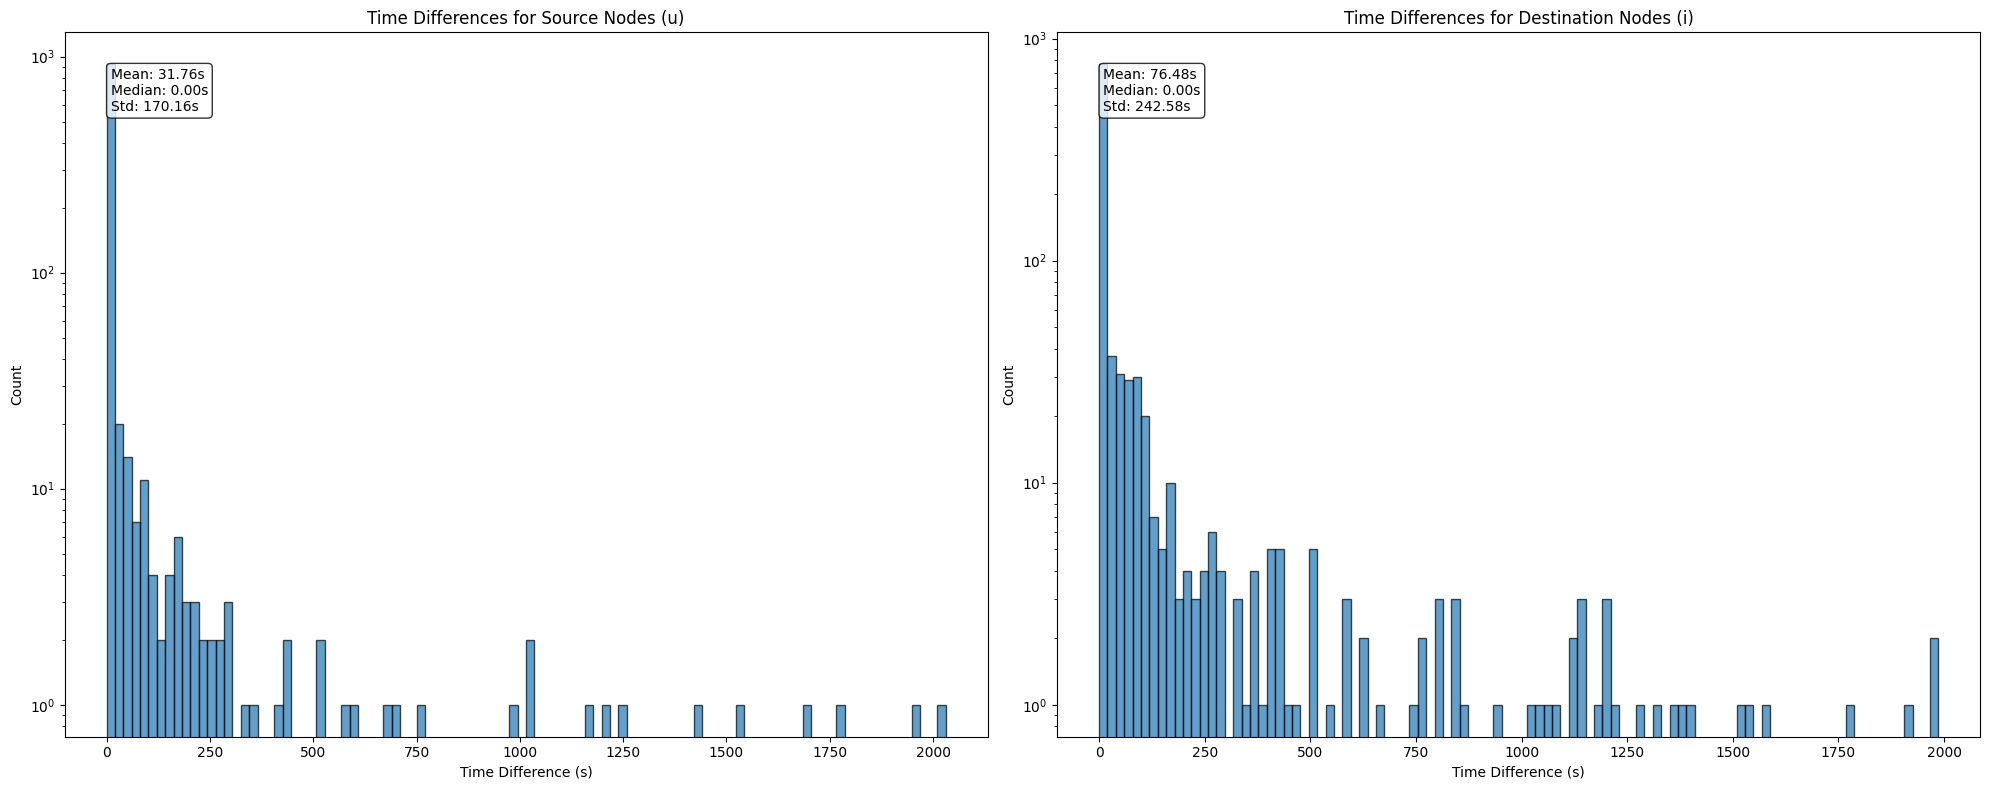

In [37]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

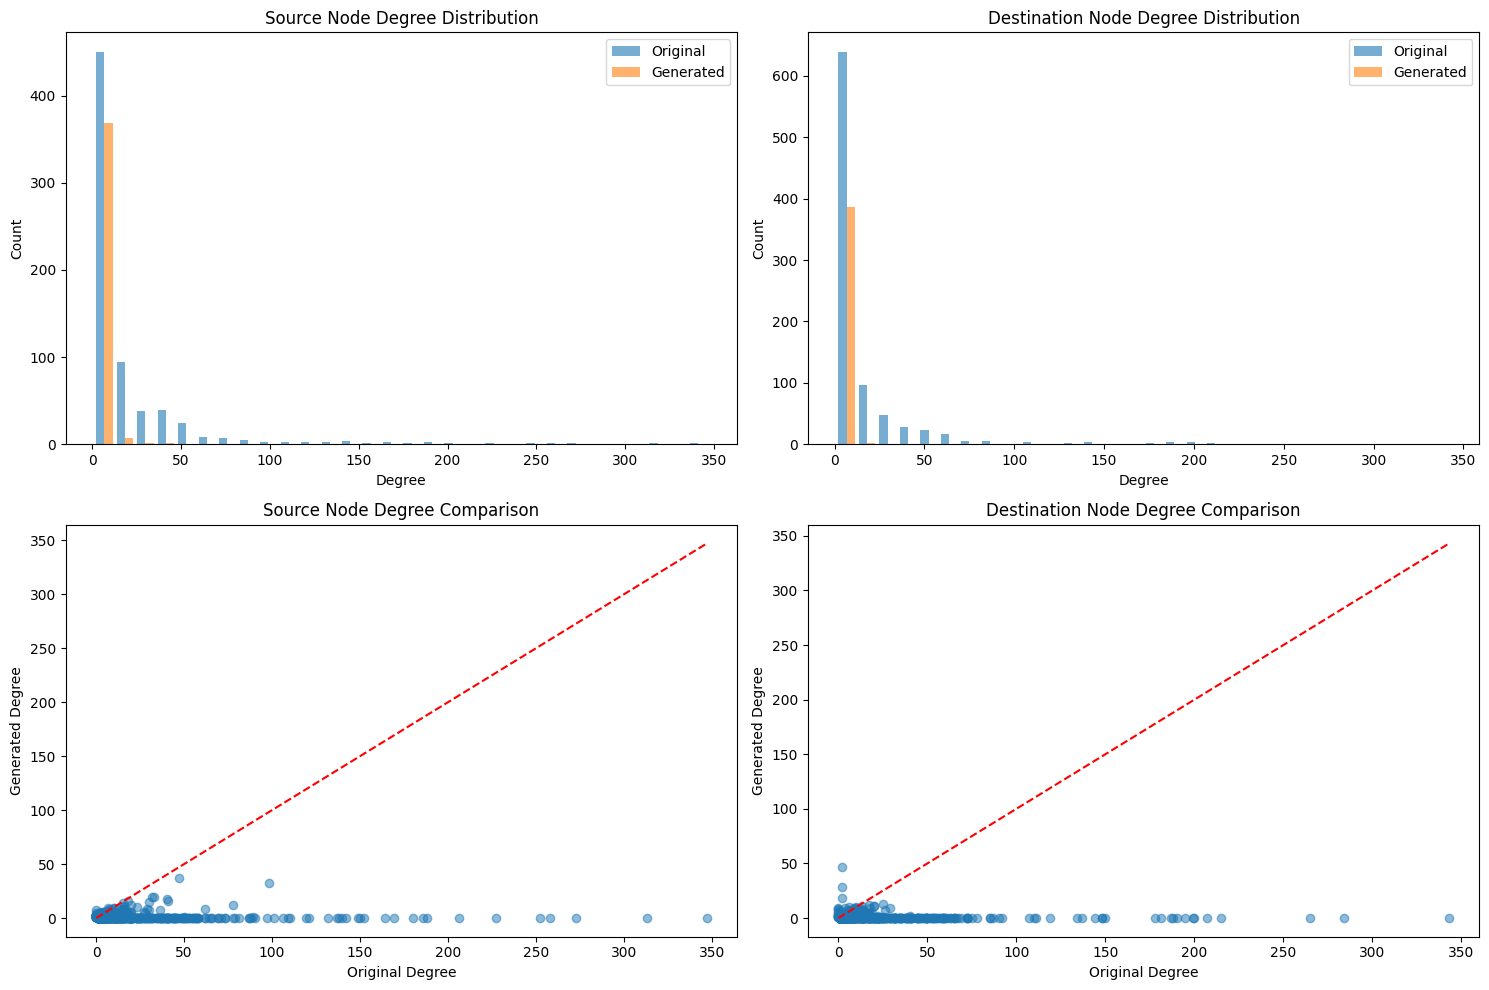

Source degree correlation: 0.009
Destination degree correlation: -0.121


In [38]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")
    

# use
plot_degree_comparison(all_missing_edges, ns_df)

In [39]:
new_edges[0]

(809, 573, 2089366.2492389395)

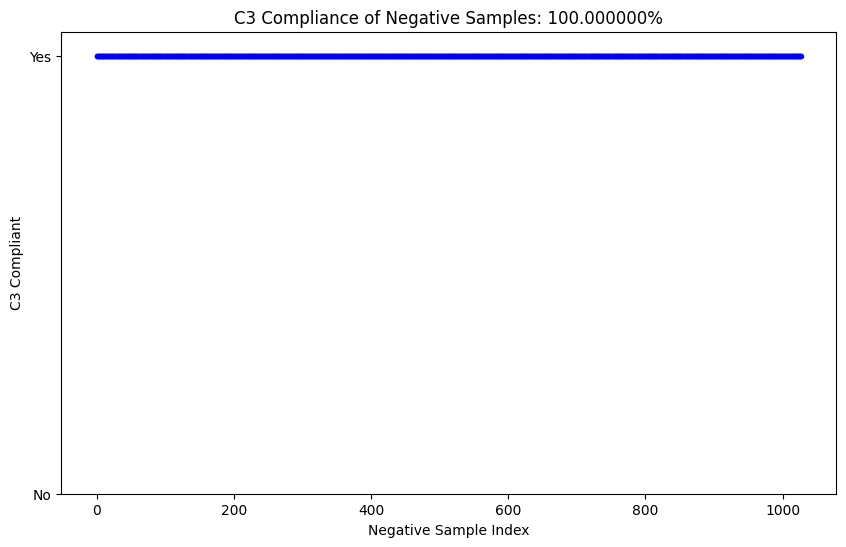

In [40]:
compliant = check_c3_compliance_optimized(all_missing_edges, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant):.6%}')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

In [41]:
# TODO: Check for full dataset.
# TODO: Can we make it 100% C3 compliant?

In [42]:
# TODO: Check for Tspear poisoned data also.
# TODO: Chekc if T-Spear is 100% compliant or not.